In [1]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [2]:
training = pd.read_csv("../training_data.csv", encoding="latin1")
test = pd.read_csv("../test_data.csv", encoding="latin1")

In [3]:
training.columns

Index(['city_name', 'record_date', 'AVERAGE_SPEED_DIFF',
       'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
       'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY', 'AVERAGE_TEMPERATURE',
       'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED',
       'AVERAGE_CLOUDINESS', 'AVERAGE_PRECIPITATION', 'AVERAGE_RAIN'],
      dtype='object')

In [4]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [5]:
training.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


<Axes: >

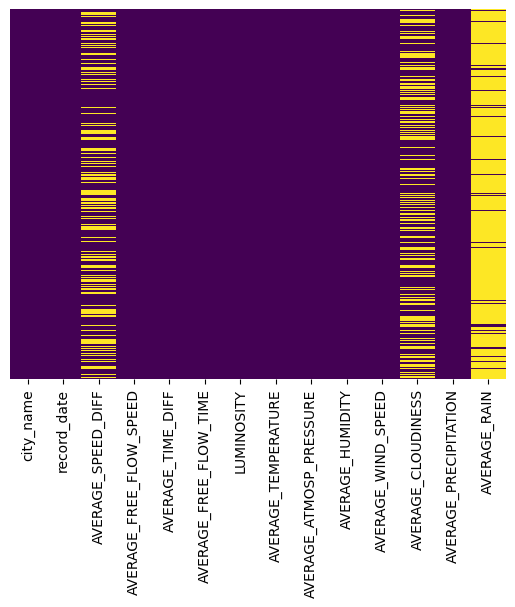

In [6]:
sns.heatmap(training.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [7]:
training.isnull().sum()

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF         2200
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64

In [8]:
training.nunique()

city_name                     1
record_date                6812
AVERAGE_SPEED_DIFF            4
AVERAGE_FREE_FLOW_SPEED     225
AVERAGE_TIME_DIFF          1151
AVERAGE_FREE_FLOW_TIME      442
LUMINOSITY                    3
AVERAGE_TEMPERATURE          38
AVERAGE_ATMOSP_PRESSURE      43
AVERAGE_HUMIDITY             77
AVERAGE_WIND_SPEED           15
AVERAGE_CLOUDINESS            9
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                 13
dtype: int64

# *Data pre-processing*

In [9]:
# Dropping unique values

training.drop('city_name', axis=1, inplace=True)
test.drop('city_name', axis=1, inplace=True)

training.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)
test.drop('AVERAGE_PRECIPITATION', axis=1, inplace=True)

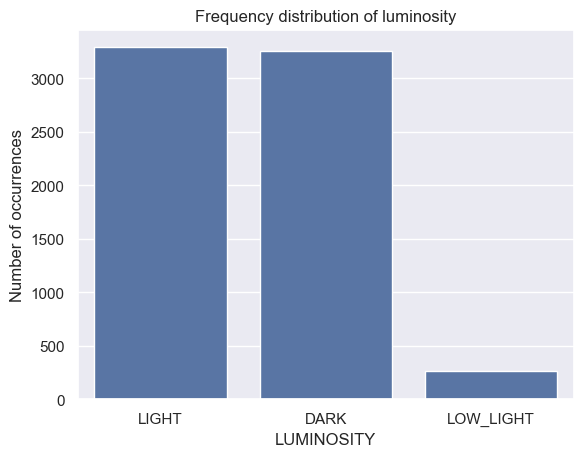

In [10]:
# Handling categorical data ... for LUMINOSITY

lum_count = training['LUMINOSITY'].value_counts()
sns.set(style='darkgrid')
sns.barplot(x=lum_count.index, y=lum_count.values)
plt.title('Frequency distribution of luminosity')
plt.ylabel('Number of occurrences', fontsize=12)
plt.xlabel('LUMINOSITY', fontsize=12)
plt.show()

In [11]:
# Using the factorising technique

training['LUMINOSITY'] = pd.factorize(training['LUMINOSITY'])[0]+1
test['LUMINOSITY'] = pd.factorize(test['LUMINOSITY'])[0]+1

In [12]:
cloudiness_training = pd.get_dummies(training['AVERAGE_CLOUDINESS'], drop_first=True)
cloudiness_test = pd.get_dummies(test['AVERAGE_CLOUDINESS'], drop_first=True)
rain_training = pd.get_dummies(training['AVERAGE_RAIN'], drop_first=True)
rain_test = pd.get_dummies(test['AVERAGE_RAIN'], drop_first=True)

training.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
training = pd.concat([training,cloudiness_training, rain_training], axis=1)

test.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1, inplace=True)
test = pd.concat([test,cloudiness_test, rain_test], axis=1)

In [13]:
training.head()

,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,...,chuva de intensidade pesada,chuva de intensidade pesado,chuva forte,chuva fraca,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve
0,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,...,False,False,False,False,False,False,False,False,False,False
1,2018-08-10 14:00:00,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,...,False,False,False,False,False,False,False,False,False,False
2,2019-09-01 16:00:00,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,...,False,False,False,False,False,False,False,False,False,False
3,2019-02-26 11:00:00,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,...,False,False,False,False,False,False,False,False,False,False
4,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,...,False,False,False,False,False,False,False,False,False,False


In [14]:
training = training.dropna(subset=['record_date'])
training['record_date'] = pd.to_datetime(training['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert training['record_date'].isnull().sum() == 0, 'missing record date'
print(training['record_date'].head())

test = test.dropna(subset=['record_date'])
test['record_date'] = pd.to_datetime(test['record_date'], format = '%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert test['record_date'].isnull().sum() == 0, 'missing record date'
print(test['record_date'].head())


0   2019-08-29 07:00:00
1   2018-08-10 14:00:00
2   2019-09-01 16:00:00
3   2019-02-26 11:00:00
4   2019-06-06 12:00:00
Name: record_date, dtype: datetime64[ns]
0   2019-02-13 23:00:00
1   2018-11-28 20:00:00
2   2018-08-14 05:00:00
3   2019-07-06 17:00:00
4   2018-10-15 06:00:00
Name: record_date, dtype: datetime64[ns]


In [15]:
training['record_date_year'] = training['record_date'].dt.year
training['record_date_month'] = training['record_date'].dt.month
training['record_date_day'] = training['record_date'].dt.day
training['record_date_hour'] = training['record_date'].dt.hour
training['record_date_minute'] = training['record_date'].dt.minute
training['record_date_second'] = training['record_date'].dt.second
training.head()

test['record_date_year'] = test['record_date'].dt.year
test['record_date_month'] = test['record_date'].dt.month
test['record_date_day'] = test['record_date'].dt.day
test['record_date_hour'] = test['record_date'].dt.hour
test['record_date_minute'] = test['record_date'].dt.minute
test['record_date_second'] = test['record_date'].dt.second
test.head()

,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour,record_date_minute,record_date_second
0,2019-02-13 23:00:00,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,True,...,False,False,False,False,2019,2,13,23,0,0
1,2018-11-28 20:00:00,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,False,...,False,False,False,False,2018,11,28,20,0,0
2,2018-08-14 05:00:00,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,False,...,False,False,False,False,2018,8,14,5,0,0
3,2019-07-06 17:00:00,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,False,...,False,False,False,False,2019,7,6,17,0,0
4,2018-10-15 06:00:00,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,False,...,False,False,False,False,2018,10,15,6,0,0


In [16]:
training.nunique()

record_date                    6812
AVERAGE_SPEED_DIFF                4
AVERAGE_FREE_FLOW_SPEED         225
AVERAGE_TIME_DIFF              1151
AVERAGE_FREE_FLOW_TIME          442
LUMINOSITY                        3
AVERAGE_TEMPERATURE              38
AVERAGE_ATMOSP_PRESSURE          43
AVERAGE_HUMIDITY                 77
AVERAGE_WIND_SPEED               15
céu claro                         2
céu limpo                         2
céu pouco nublado                 2
nublado                           2
nuvens dispersas                  2
nuvens quebradas                  2
nuvens quebrados                  2
tempo nublado                     2
aguaceiros fracos                 2
chuva                             2
chuva de intensidade pesada       2
chuva de intensidade pesado       2
chuva forte                       2
chuva fraca                       2
chuva leve                        2
chuva moderada                    2
chuvisco e chuva fraca            2
chuvisco fraco              

In [17]:
test.nunique()

record_date                1500
AVERAGE_FREE_FLOW_SPEED     199
AVERAGE_TIME_DIFF           610
AVERAGE_FREE_FLOW_TIME      337
LUMINOSITY                    3
AVERAGE_TEMPERATURE          32
AVERAGE_ATMOSP_PRESSURE      42
AVERAGE_HUMIDITY             70
AVERAGE_WIND_SPEED           14
céu claro                     2
céu limpo                     2
céu pouco nublado             2
nublado                       2
nuvens dispersas              2
nuvens quebradas              2
nuvens quebrados              2
tempo nublado                 2
aguaceiros fracos             2
chuva                         2
chuva fraca                   2
chuva leve                    2
chuva moderada                2
chuvisco fraco                2
trovoada com chuva            2
trovoada com chuva leve       2
record_date_year              2
record_date_month            12
record_date_day              31
record_date_hour             24
record_date_minute            1
record_date_second            1
dtype: i

In [18]:
training.isnull().sum()

record_date                       0
AVERAGE_SPEED_DIFF             2200
AVERAGE_FREE_FLOW_SPEED           0
AVERAGE_TIME_DIFF                 0
AVERAGE_FREE_FLOW_TIME            0
LUMINOSITY                        0
AVERAGE_TEMPERATURE               0
AVERAGE_ATMOSP_PRESSURE           0
AVERAGE_HUMIDITY                  0
AVERAGE_WIND_SPEED                0
céu claro                         0
céu limpo                         0
céu pouco nublado                 0
nublado                           0
nuvens dispersas                  0
nuvens quebradas                  0
nuvens quebrados                  0
tempo nublado                     0
aguaceiros fracos                 0
chuva                             0
chuva de intensidade pesada       0
chuva de intensidade pesado       0
chuva forte                       0
chuva fraca                       0
chuva leve                        0
chuva moderada                    0
chuvisco e chuva fraca            0
chuvisco fraco              

In [19]:
# Dropping unique date values

training.drop('record_date_minute', axis=1, inplace=True)
training.drop('record_date_second', axis=1, inplace=True)
training.drop('record_date', axis=1, inplace=True)
#training.dropna(inplace=True)
training.head()

test.drop('record_date_minute', axis=1, inplace=True)
test.drop('record_date_second', axis=1, inplace=True)
test.drop('record_date', axis=1, inplace=True)
test.dropna(inplace=True)
test.head()


,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,céu limpo,...,chuva fraca,chuva leve,chuva moderada,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,39.2,0.0,91.0,1,8.0,1026.0,71.0,1.0,True,False,...,False,False,False,False,False,False,2019,2,13,23
1,42.5,12.2,76.8,1,11.0,1020.0,93.0,4.0,False,False,...,False,False,False,False,False,False,2018,11,28,20
2,45.9,0.0,86.3,1,14.0,1017.0,93.0,0.0,False,False,...,False,False,False,False,False,False,2018,8,14,5
3,33.2,51.7,89.9,2,22.0,1016.0,77.0,4.0,False,False,...,False,False,False,False,False,False,2019,7,6,17
4,44.0,3.5,85.5,1,12.0,1004.0,100.0,9.0,False,False,...,True,False,False,False,False,False,2018,10,15,6


In [20]:
training.head()

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,False,...,False,False,False,False,False,False,2019,8,29,7
1,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,True,...,False,False,False,False,False,False,2018,8,10,14
2,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,False,...,False,False,False,False,False,False,2019,9,1,16
3,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,True,...,False,False,False,False,False,False,2019,2,26,11
4,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,False,...,False,False,False,False,False,False,2019,6,6,12


# *Training model*

In [21]:
# Preparar X_train e y_train
X_train_full = training.drop('AVERAGE_SPEED_DIFF', axis=1)
y_train_full = training['AVERAGE_SPEED_DIFF']

# X_test é o test completo (não tem AVERAGE_SPEED_DIFF)
X_test = test.copy()

print("Antes do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")

# Adicionar colunas que existem no training mas não no test
missing_cols = set(X_train_full.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
    print(f"Adicionada coluna '{col}' ao test")

# Remover colunas que existem no test mas não no training
extra_cols = set(X_test.columns) - set(X_train_full.columns)
if len(extra_cols) > 0:
    X_test.drop(list(extra_cols), axis=1, inplace=True)
    print(f"Removidas {len(extra_cols)} colunas extra do test")

# Reordenar colunas do test para ficarem na mesma ordem que o training
X_test = X_test[X_train_full.columns]

print("\nDepois do alinhamento:")
print(f"X_train: {X_train_full.shape}")
print(f"X_test: {X_test.shape}")
print(f"Colunas coincidem: {list(X_train_full.columns) == list(X_test.columns)}")

Antes do alinhamento:
X_train: (6812, 32)
X_test: (1500, 28)
X_train: (6812, 32)
X_test: (1500, 28)
Adicionada coluna 'chuvisco e chuva fraca' ao test
Adicionada coluna 'chuva forte' ao test
Adicionada coluna 'chuva de intensidade pesado' ao test
Adicionada coluna 'chuva de intensidade pesada' ao test

Depois do alinhamento:
X_train: (6812, 32)
X_test: (1500, 32)
Colunas coincidem: True


In [22]:
y_train_full.fillna("None", inplace=True)

In [23]:
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
None         2200
Medium       1651
Low          1419
High         1063
Very_High     479
Name: count, dtype: int64

In [24]:
mapper = {"None": 0, "Low": 1, "Medium": 2, "High": 3, "Very_High": 4}
y_train_full = y_train_full.map(mapper)
y_train_full.value_counts()

AVERAGE_SPEED_DIFF
0    2200
2    1651
1    1419
3    1063
4     479
Name: count, dtype: int64

# *Redes Neuronais*

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled  = scaler.transform(X_test)


In [26]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
X_tr_tensor  = torch.tensor(X_tr, dtype=torch.float32)
y_tr_tensor  = torch.tensor(y_tr.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [27]:
import torch.nn as nn
import torch.nn.functional as F

class NeuralNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [29]:
model = NeuralNet(X_tr_tensor.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [30]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for Xb, yb in loader:
            outputs = model(Xb)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total


In [31]:
epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_acc = accuracy(model, train_loader)
    val_acc   = accuracy(model, val_loader)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Epoch 1/50 | Loss: 1.0660 | Train Acc: 0.6777 | Val Acc: 0.6720
Epoch 2/50 | Loss: 0.6910 | Train Acc: 0.7392 | Val Acc: 0.7322
Epoch 3/50 | Loss: 0.6012 | Train Acc: 0.7631 | Val Acc: 0.7608
Epoch 4/50 | Loss: 0.5606 | Train Acc: 0.7822 | Val Acc: 0.7608
Epoch 5/50 | Loss: 0.5292 | Train Acc: 0.7767 | Val Acc: 0.7601
Epoch 6/50 | Loss: 0.5167 | Train Acc: 0.7884 | Val Acc: 0.7792
Epoch 7/50 | Loss: 0.5036 | Train Acc: 0.8018 | Val Acc: 0.7806
Epoch 8/50 | Loss: 0.4891 | Train Acc: 0.8029 | Val Acc: 0.7660
Epoch 9/50 | Loss: 0.4832 | Train Acc: 0.8046 | Val Acc: 0.7755
Epoch 10/50 | Loss: 0.4768 | Train Acc: 0.8079 | Val Acc: 0.7682
Epoch 11/50 | Loss: 0.4730 | Train Acc: 0.8126 | Val Acc: 0.7733
Epoch 12/50 | Loss: 0.4575 | Train Acc: 0.8053 | Val Acc: 0.7799
Epoch 13/50 | Loss: 0.4574 | Train Acc: 0.8110 | Val Acc: 0.7718
Epoch 14/50 | Loss: 0.4553 | Train Acc: 0.8202 | Val Acc: 0.7689
Epoch 15/50 | Loss: 0.4469 | Train Acc: 0.8178 | Val Acc: 0.7740
Epoch 16/50 | Loss: 0.4430 | Train

In [32]:
final_train_acc = accuracy(model, train_loader)
final_val_acc   = accuracy(model, val_loader)

print("\nAccuracy final após o treino:")
print(f"Treino: {final_train_acc*100:.2f}%")
print(f"Validação: {final_val_acc*100:.2f}%")


Accuracy final após o treino:
Treino: 86.27%
Validação: 75.28%


In [36]:
model.eval()
with torch.no_grad():
    test_preds = torch.argmax(model(X_test_tensor), dim=1).numpy()

reverse_mapper = {0: "None", 1: "Low", 2: "Medium", 3: "High", 4: "Very_High"}
test_preds = pd.Series(test_preds).map(reverse_mapper)

output = pd.DataFrame({
    'RowId': range(1, len(test_preds) + 1),
    'Speed_Diff': test_preds
})

output.to_csv('../predictions/NeuralNetwork.csv', index=False)
print("Previsões salvas em 'NeuralNetwork.csv'")


Previsões salvas em 'NeuralNetwork.csv'


In [34]:
training.head()

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,céu claro,...,chuva leve,chuva moderada,chuvisco e chuva fraca,chuvisco fraco,trovoada com chuva,trovoada com chuva leve,record_date_year,record_date_month,record_date_day,record_date_hour
0,Medium,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,False,...,False,False,False,False,False,False,2019,8,29,7
1,High,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,True,...,False,False,False,False,False,False,2018,8,10,14
2,High,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,False,...,False,False,False,False,False,False,2019,9,1,16
3,High,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,True,...,False,False,False,False,False,False,2019,2,26,11
4,Medium,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,False,...,False,False,False,False,False,False,2019,6,6,12
